In [5]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

In [7]:
def read_dos(filename: str) -> Tuple[np.ndarray, np.ndarray]:
    ener, dos = np.loadtxt(filename, usecols=(0,1), unpack=True)
    return ener, dos

In [3]:
! head 'ZnO_PBEplusU.dos'

#  E (eV)   dos(E)     Int dos(E) EFermi =    4.814 eV
  -9.963  0.1209E-04  0.1209E-06
  -9.953  0.1794E-02  0.1806E-04
  -9.943  0.3604E-01  0.3784E-03
  -9.933  0.9846E-01  0.1363E-02
  -9.923  0.6231E-01  0.1986E-02
  -9.913  0.2401E+00  0.4388E-02
  -9.903  0.6337E+00  0.1072E-01
  -9.893  0.4816E+00  0.1554E-01
  -9.883  0.6426E+00  0.2197E-01


In [14]:
! ls *atm*

'ZnO_PBEplusU.pdos_atm#1(Zn)_wfc#1(s)'	'ZnO_PBEplusU.pdos_atm#2(Zn)_wfc#3(d)'
'ZnO_PBEplusU.pdos_atm#1(Zn)_wfc#2(p)'	'ZnO_PBEplusU.pdos_atm#3(O)_wfc#1(s)'
'ZnO_PBEplusU.pdos_atm#1(Zn)_wfc#3(d)'	'ZnO_PBEplusU.pdos_atm#3(O)_wfc#2(p)'
'ZnO_PBEplusU.pdos_atm#2(Zn)_wfc#1(s)'	'ZnO_PBEplusU.pdos_atm#4(O)_wfc#1(s)'
'ZnO_PBEplusU.pdos_atm#2(Zn)_wfc#2(p)'	'ZnO_PBEplusU.pdos_atm#4(O)_wfc#2(p)'


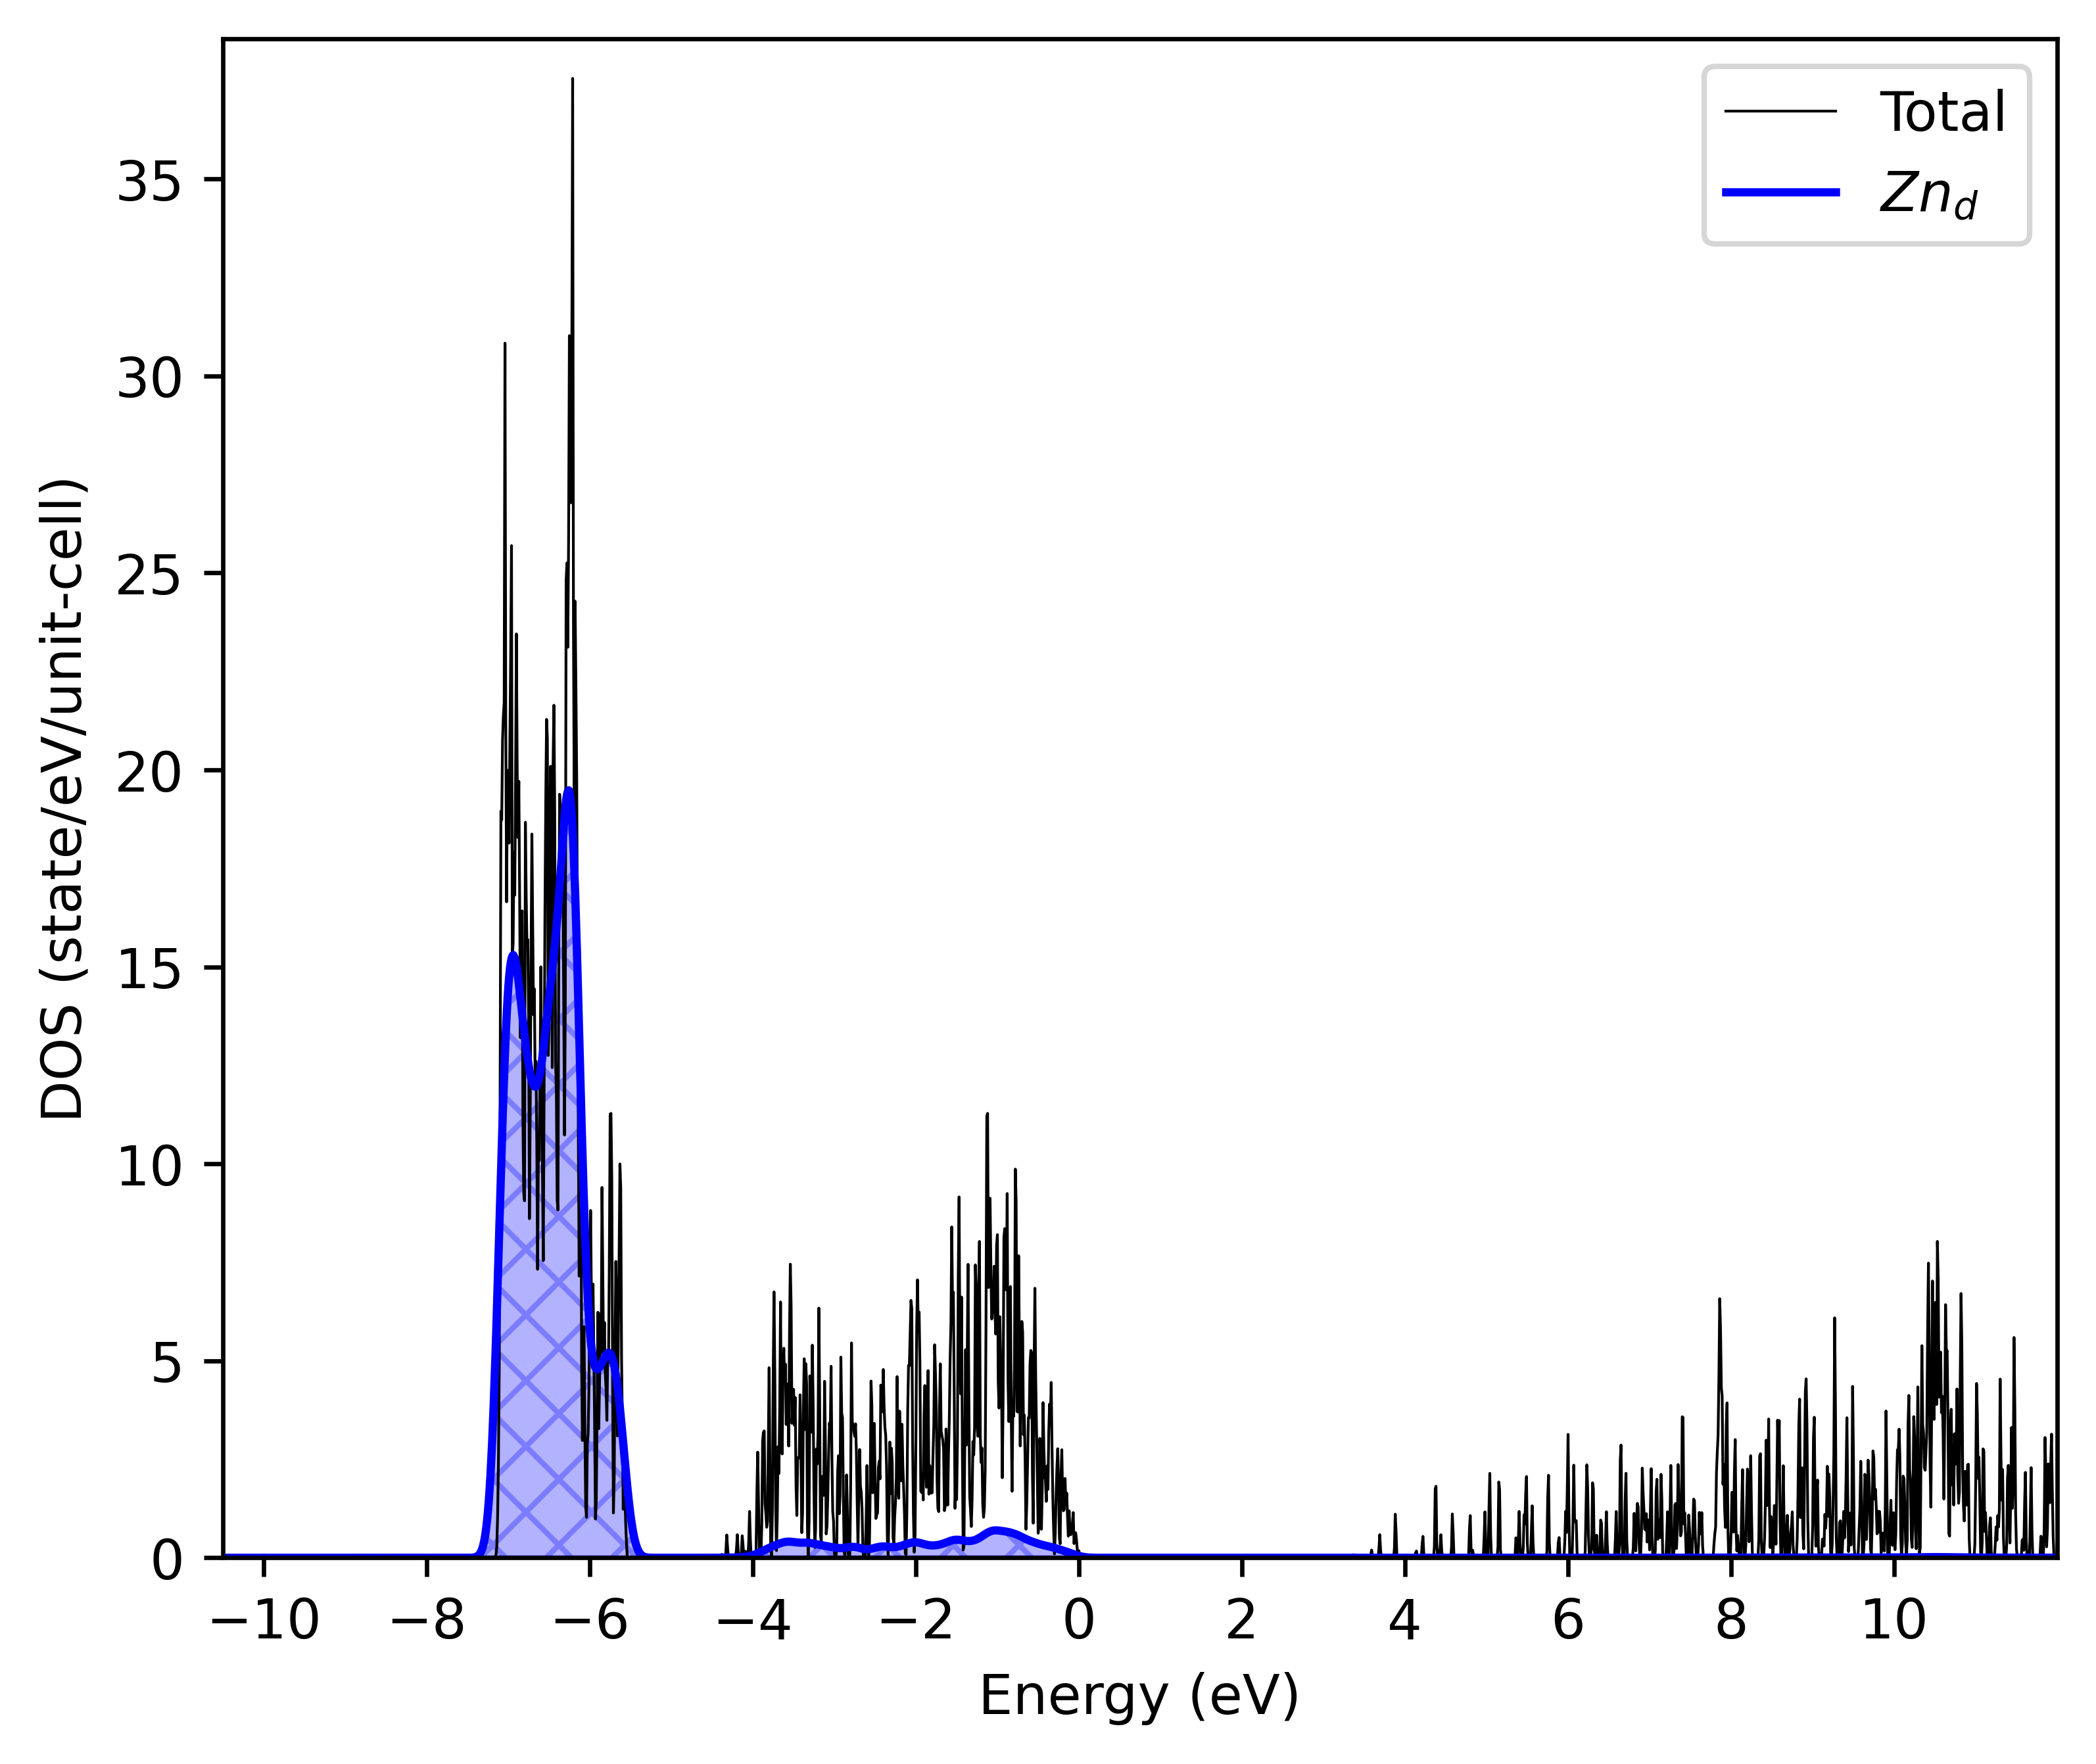

In [59]:
# Total Density of States
ener, dos = read_dos('ZnO_PBEplusU.dos')

# PDOS for Zn d states
ener1, p1_znd = read_dos('ZnO_PBEplusU.pdos_atm#1(Zn)_wfc#3(d)') # atm1
ener2, p2_znd = read_dos('ZnO_PBEplusU.pdos_atm#2(Zn)_wfc#3(d)') # atm2


EFermi = 4.814 # eV

# Plotting
plt.figure(figsize=(6,5), dpi=600)
plt.plot(ener-EFermi, dos, c='k', label='Total', linewidth=0.5)

# Zn 3d states
plt.plot(ener1-EFermi, p1_znd+p2_znd, c='b', label=r'$Zn_{d}$')
# Preenchimento sob a curva
plt.fill_between(ener1 - EFermi, p1_znd + p2_znd, color='b', alpha=0.3, hatch='xx')

# Add the x and y-axis labels
plt.xlabel('Energy (eV)')
plt.ylabel('DOS (state/eV/unit-cell)')

plt.xlim((-10.5,12))
plt.xticks(range(-10,12,2))
plt.ylim(0, dos.max() + 1)
plt.savefig("Dos_pdos_d_states.svg", format="svg", bbox_inches="tight")
plt.legend()
plt.show()

##### __Reference 1__: Dielectric properties and Raman spectra of ZnO from a first principles finite-differences/finite-fields approach
<div align='center'>

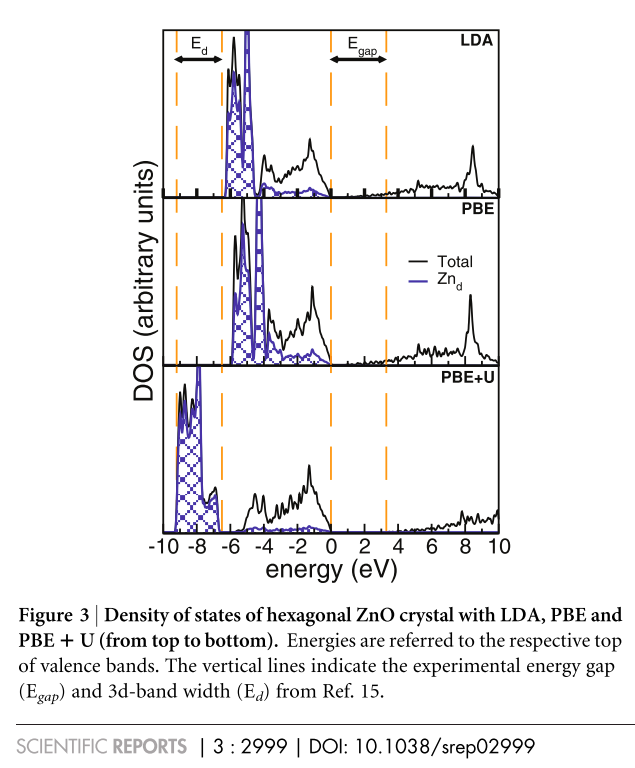

</div>

#### __Reference 2__: Structural and electronic properties of ZnO: A first-principles density-functional theory study within LDA(GGA) and LDA(GGA)+U methods

<div align="center">

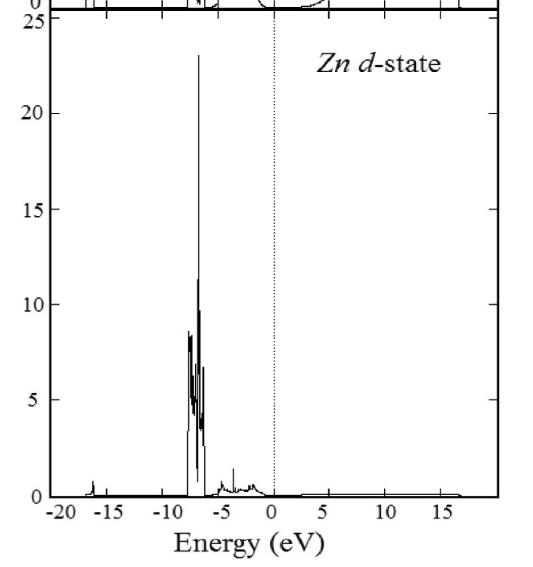

<div>